# Plot Synthetic IMU Data
Quick visualisation of virtual IMU signals produced by the POSE2IMU pipeline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
SENSOR_NAMES = ["waist", "head", "right_forearm", "left_forearm"]
CHANNELS     = ["ax", "ay", "az", "gx", "gy", "gz"]
ACC_IDX      = [0, 1, 2]   # accelerometer channels
GYR_IDX      = [3, 4, 5]   # gyroscope channels

ROOT = Path("../output/robot_emotions_virtual_imu")

all_files = sorted(ROOT.rglob("imu.npz"))
print(f"Found {len(all_files)} virtual IMU files")
for f in all_files[:5]:
    print(" ", f.relative_to(ROOT))

Found 89 virtual IMU files
  10ms/user_02/robot_emotions_10ms_u02_tag01/imu.npz
  10ms/user_02/robot_emotions_10ms_u02_tag05/imu.npz
  10ms/user_02/robot_emotions_10ms_u02_tag06/imu.npz
  10ms/user_02/robot_emotions_10ms_u02_tag07/imu.npz
  10ms/user_02/robot_emotions_10ms_u02_tag09/imu.npz


In [3]:
# Pick one clip to inspect — change the index to explore others
FILE_IDX = 0

path = all_files[FILE_IDX]
data = np.load(path, allow_pickle=True)

t   = data["timestamps_sec"]          # (T,)
imu = data["imu"]                     # (T, 4, 6)

# Relative time starting from 0
t = t - t[0]

print(f"Clip : {path.parent.name}")
print(f"Shape: {imu.shape}  →  {imu.shape[0]} frames, {imu.shape[1]} sensors, {imu.shape[2]} channels")
print(f"Duration: {t[-1]:.1f} s")

Clip : robot_emotions_10ms_u02_tag01
Shape: (11590, 4, 6)  →  11590 frames, 4 sensors, 6 channels
Duration: 105.8 s


## All sensors — accelerometer + gyroscope

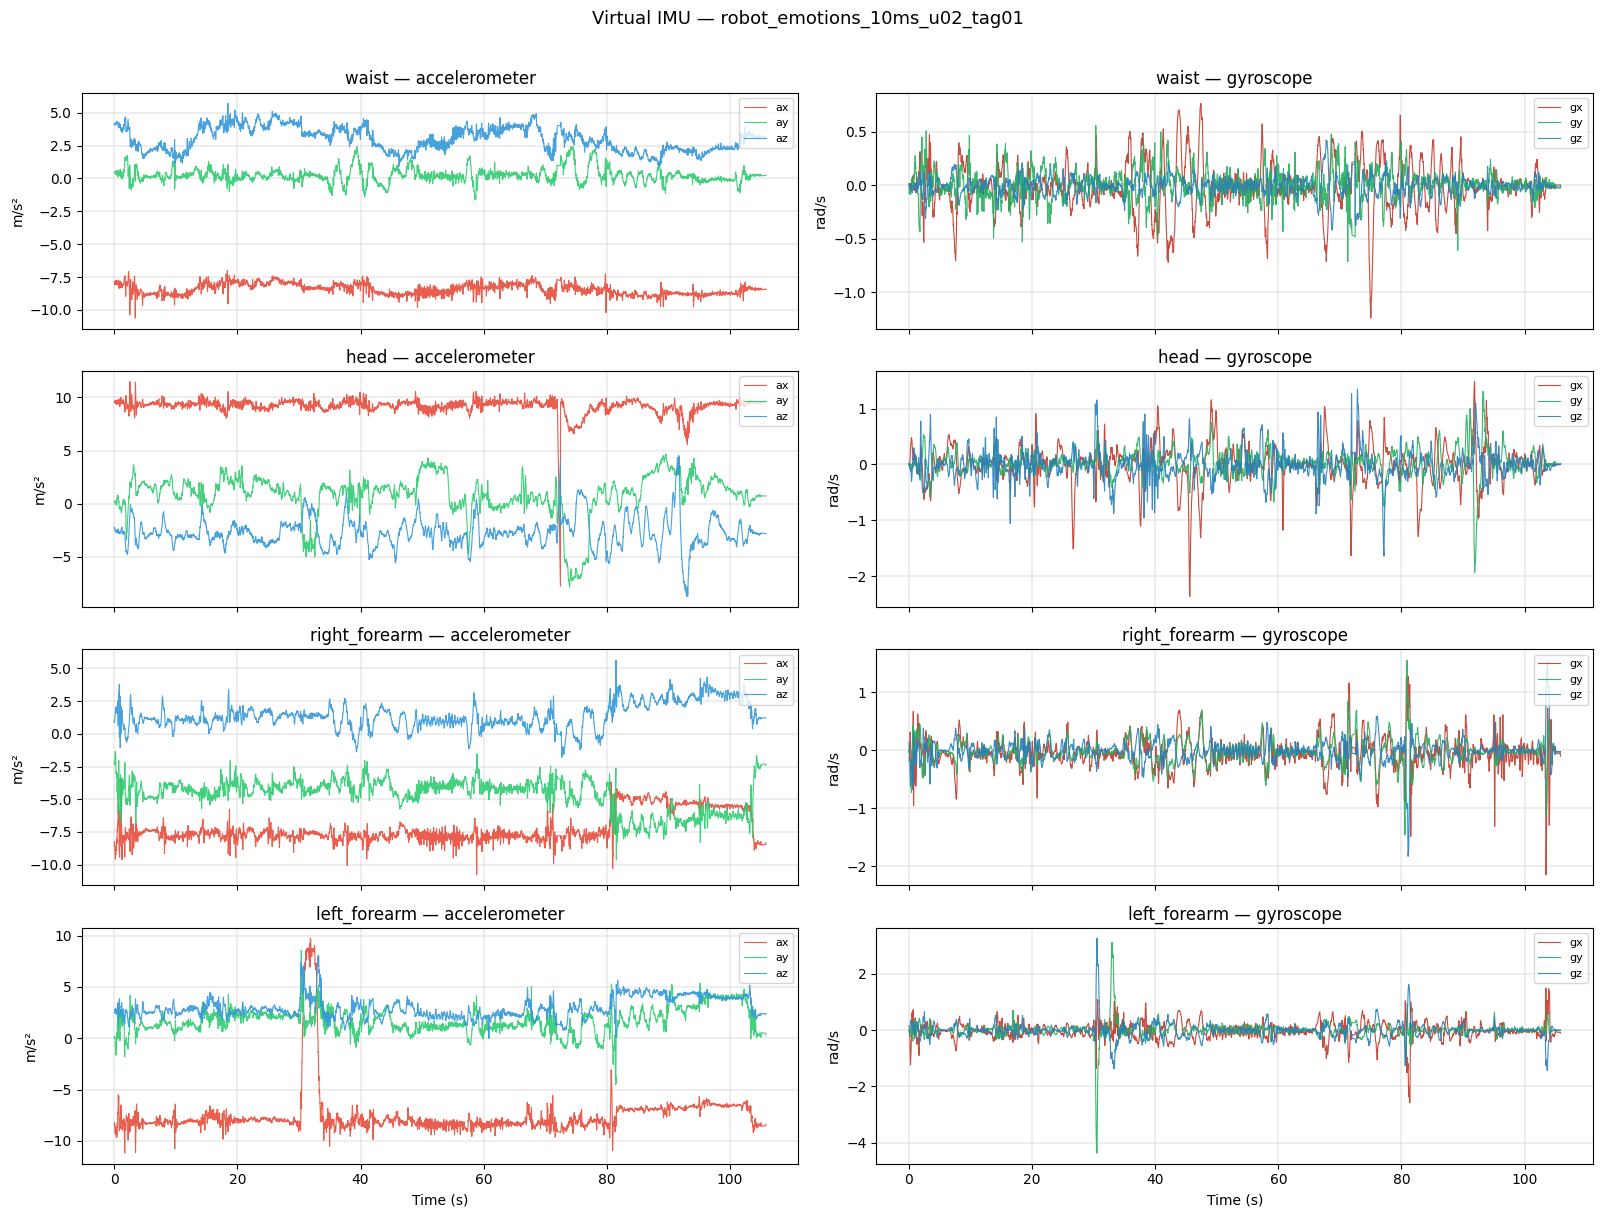

In [4]:
fig, axes = plt.subplots(len(SENSOR_NAMES), 2, figsize=(16, 3 * len(SENSOR_NAMES)), sharex=True)
fig.suptitle(f"Virtual IMU — {path.parent.name}", fontsize=13, y=1.01)

colors_acc = ["#e74c3c", "#2ecc71", "#3498db"]   # x=red, y=green, z=blue
colors_gyr = ["#c0392b", "#27ae60", "#2980b9"]

for s, (sensor, row) in enumerate(zip(SENSOR_NAMES, axes)):
    ax_acc, ax_gyr = row

    for i, idx in enumerate(ACC_IDX):
        ax_acc.plot(t, imu[:, s, idx], color=colors_acc[i], lw=0.8, alpha=0.9, label=CHANNELS[idx])
    ax_acc.set_ylabel("m/s²")
    ax_acc.set_title(f"{sensor} — accelerometer")
    ax_acc.legend(loc="upper right", fontsize=8)
    ax_acc.grid(True, lw=0.3)

    for i, idx in enumerate(GYR_IDX):
        ax_gyr.plot(t, imu[:, s, idx], color=colors_gyr[i], lw=0.8, alpha=0.9, label=CHANNELS[idx])
    ax_gyr.set_ylabel("rad/s")
    ax_gyr.set_title(f"{sensor} — gyroscope")
    ax_gyr.legend(loc="upper right", fontsize=8)
    ax_gyr.grid(True, lw=0.3)

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## Accelerometer norm (magnitude) per sensor

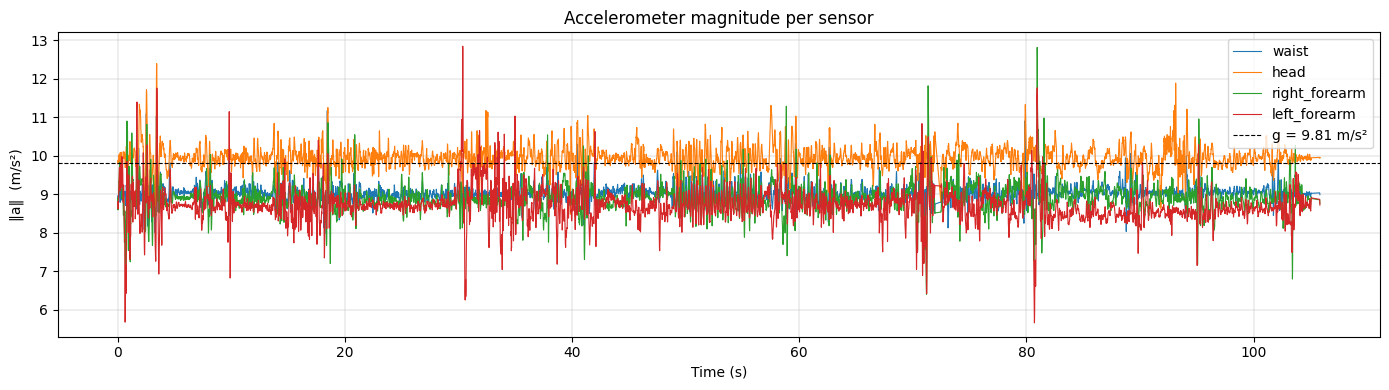

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
for s, sensor in enumerate(SENSOR_NAMES):
    norm = np.linalg.norm(imu[:, s, :3], axis=-1)
    ax.plot(t, norm, lw=0.8, label=sensor)

ax.axhline(9.81, color="k", lw=0.8, ls="--", label="g = 9.81 m/s²")
ax.set_xlabel("Time (s)")
ax.set_ylabel("‖a‖  (m/s²)")
ax.set_title("Accelerometer magnitude per sensor")
ax.legend()
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

## Compare multiple clips — waist accelerometer

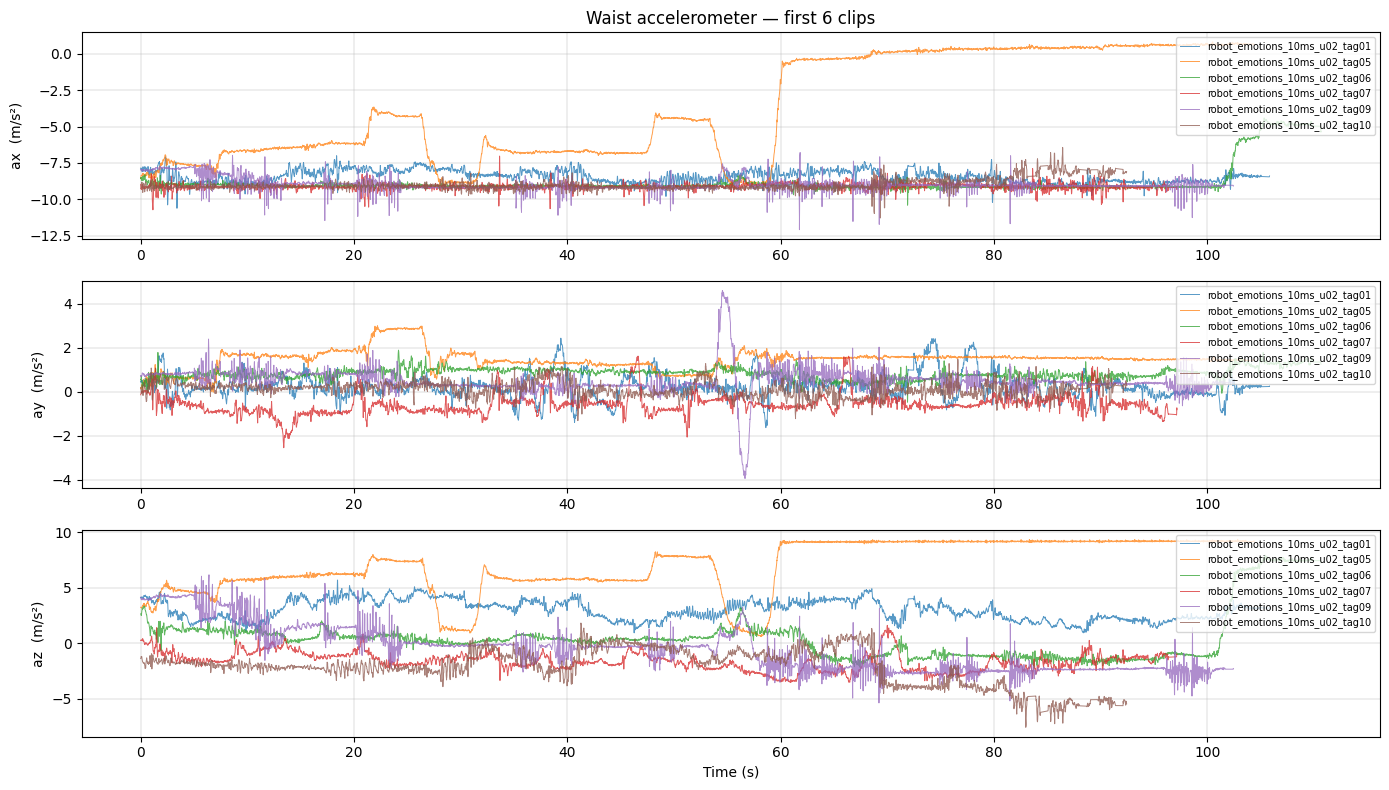

In [6]:
N_CLIPS   = 6    # how many clips to overlay
SENSOR_I  = 0    # 0=waist, 1=head, 2=right_forearm, 3=left_forearm

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)
axis_labels = ["ax", "ay", "az"]

for clip_path in all_files[:N_CLIPS]:
    d  = np.load(clip_path, allow_pickle=True)
    tc = d["timestamps_sec"]
    tc = tc - tc[0]
    sig = d["imu"][:, SENSOR_I, :3]   # (T, 3) accelerometer
    label = clip_path.parent.name[-30:]
    for ch in range(3):
        axes[ch].plot(tc, sig[:, ch], lw=0.7, alpha=0.75, label=label)

for ch, ax in enumerate(axes):
    ax.set_ylabel(f"{axis_labels[ch]}  (m/s²)")
    ax.grid(True, lw=0.3)
    ax.legend(fontsize=7, loc="upper right")

axes[-1].set_xlabel("Time (s)")
axes[0].set_title(f"Waist accelerometer — first {N_CLIPS} clips")
plt.tight_layout()
plt.show()

## Signal statistics summary

In [7]:
print(f"{'Sensor':<15} {'Channel':<6} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 55)
for s, sensor in enumerate(SENSOR_NAMES):
    for c, ch in enumerate(CHANNELS):
        vals = imu[:, s, c]
        print(f"{sensor:<15} {ch:<6} {vals.mean():>8.3f} {vals.std():>8.3f} {vals.min():>8.3f} {vals.max():>8.3f}")
    print()

Sensor          Channel     Mean      Std      Min      Max
-------------------------------------------------------
waist           ax       -8.437    0.422  -10.613   -7.002
waist           ay        0.232    0.550   -1.641    2.425
waist           az        2.994    0.906    0.952    5.713
waist           gx       -0.014    0.229   -1.241    0.767
waist           gy        0.005    0.126   -0.715    0.560
waist           gz       -0.010    0.086   -0.417    0.422

head            ax        9.204    0.592   -7.752   11.487
head            ay        0.844    2.016   -7.836    4.664
head            az       -2.700    1.384   -8.715    4.560
head            gx       -0.007    0.342   -2.361    1.480
head            gy        0.026    0.237   -1.933    1.307
head            gz       -0.009    0.260   -1.641    1.347

right_forearm   ax       -7.226    1.118  -10.764   -3.493
right_forearm   ay       -4.656    1.209   -9.628   -1.344
right_forearm   az        1.395    0.986   -1.798    5.6

---
## Real vs. Virtual — Comparative Plots
Two plots per row: **Real** (left) | **Virtual** (right).  
Rows = sensors. Accelerometers first, then gyroscopes.

In [8]:
import sys
import importlib

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import evaluation.utils as utils_module
utils_module = importlib.reload(utils_module)

from evaluation.utils import (
    build_exported_capture_table,
    select_capture_row,
    load_real_capture,
    load_virtual_capture,
)
from pose_module.processing.frequency_alignment import prepare_real_signal_for_virtual_comparison

OUTPUT_ROOT = PROJECT_ROOT / "output" / "robot_emotions_virtual_imu"
CAPTURES_DF = build_exported_capture_table(OUTPUT_ROOT)
print(f"{len(CAPTURES_DF)} captures available")
CAPTURES_DF[["clip_id", "domain", "user_id", "tag_number"]].head(8)

89 captures available


,clip_id,domain,user_id,tag_number
0,robot_emotions_10ms_u02_tag01,10ms,2,1
1,robot_emotions_10ms_u02_tag05,10ms,2,5
2,robot_emotions_10ms_u02_tag06,10ms,2,6
3,robot_emotions_10ms_u02_tag07,10ms,2,7
4,robot_emotions_10ms_u02_tag09,10ms,2,9
5,robot_emotions_10ms_u02_tag10,10ms,2,10
6,robot_emotions_10ms_u02_tag11,10ms,2,11
7,robot_emotions_10ms_u02_tag16,10ms,2,16


In [9]:
# ── Select a capture ──────────────────────────────────────────────────────────
DOMAIN     = "10ms"   # "10ms" or "30ms"
USER_ID    = 2
TAG_NUMBER = 1
TAKE_ID    = None

capture_row = select_capture_row(
    CAPTURES_DF, domain=DOMAIN, user_id=USER_ID,
    tag_number=TAG_NUMBER, take_id=TAKE_ID,
)

real_data = load_real_capture(Path(capture_row["clip_dir"]))
virt_data = load_virtual_capture(Path(capture_row["pose_dir"]))

# Sensors present in both, in real-data order
virt_sensor_set = set(virt_data["sensor_names"])
shared_sensors  = [s for s in real_data["sensor_names"] if s in virt_sensor_set]

# Resample real signal to virtual timestamps
real_acc_bundle  = prepare_real_signal_for_virtual_comparison(
    real_timestamps_sec=real_data["timestamps_sec"],
    real_values=real_data["imu"][:, :, :3],
    virtual_timestamps_sec=virt_data["timestamps_sec"],
)
real_gyro_bundle = prepare_real_signal_for_virtual_comparison(
    real_timestamps_sec=real_data["timestamps_sec"],
    real_values=real_data["imu"][:, :, 3:6],
    virtual_timestamps_sec=virt_data["timestamps_sec"],
)

real_t = real_acc_bundle["timestamps_sec"] - real_acc_bundle["timestamps_sec"][0]
virt_t = virt_data["timestamps_sec"] - virt_data["timestamps_sec"][0]

print(f"Clip          : {capture_row['clip_id']}")
print(f"Shared sensors: {shared_sensors}")
print(f"Real frames (resampled): {real_acc_bundle['values'].shape[0]}")
print(f"Virtual frames         : {virt_data['acc'].shape[0]}")

Clip          : robot_emotions_10ms_u02_tag01
Shared sensors: ['waist', 'head', 'left_forearm', 'right_forearm']
Real frames (resampled): 2086
Virtual frames         : 2086


In [10]:
def _plot_real_vs_virtual(real_t, real_sig, virt_t, virt_sig,
                           real_names, virt_names, shared_sensors,
                           axis_labels, unit, suptitle):
    """real_sig / virt_sig shape: (T, num_all_sensors, 3)"""
    colors = ["#e74c3c", "#2ecc71", "#3498db"]  # x=red, y=green, z=blue
    n = len(shared_sensors)
    fig, axes = plt.subplots(n, 2, figsize=(16, 3.5 * n), squeeze=False)
    fig.suptitle(suptitle, fontsize=13)

    for row_i, sensor in enumerate(shared_sensors):
        ri = list(real_names).index(sensor)
        vi = list(virt_names).index(sensor)
        ax_r, ax_v = axes[row_i]

        for ch_i, lbl in enumerate(axis_labels):
            ax_r.plot(real_t, real_sig[:, ri, ch_i],
                      color=colors[ch_i], lw=0.8, alpha=0.9, label=lbl)
            ax_v.plot(virt_t, virt_sig[:, vi, ch_i],
                      color=colors[ch_i], lw=0.8, alpha=0.9, label=lbl)

        for ax, title in [(ax_r, f"{sensor} — Real"),
                          (ax_v, f"{sensor} — Virtual")]:
            ax.set_ylabel(unit)
            ax.set_title(title)
            ax.legend(loc="upper right", fontsize=8)
            ax.grid(True, lw=0.3)

    axes[-1, 0].set_xlabel("Time (s)")
    axes[-1, 1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

### Accelerometers — Real vs. Virtual

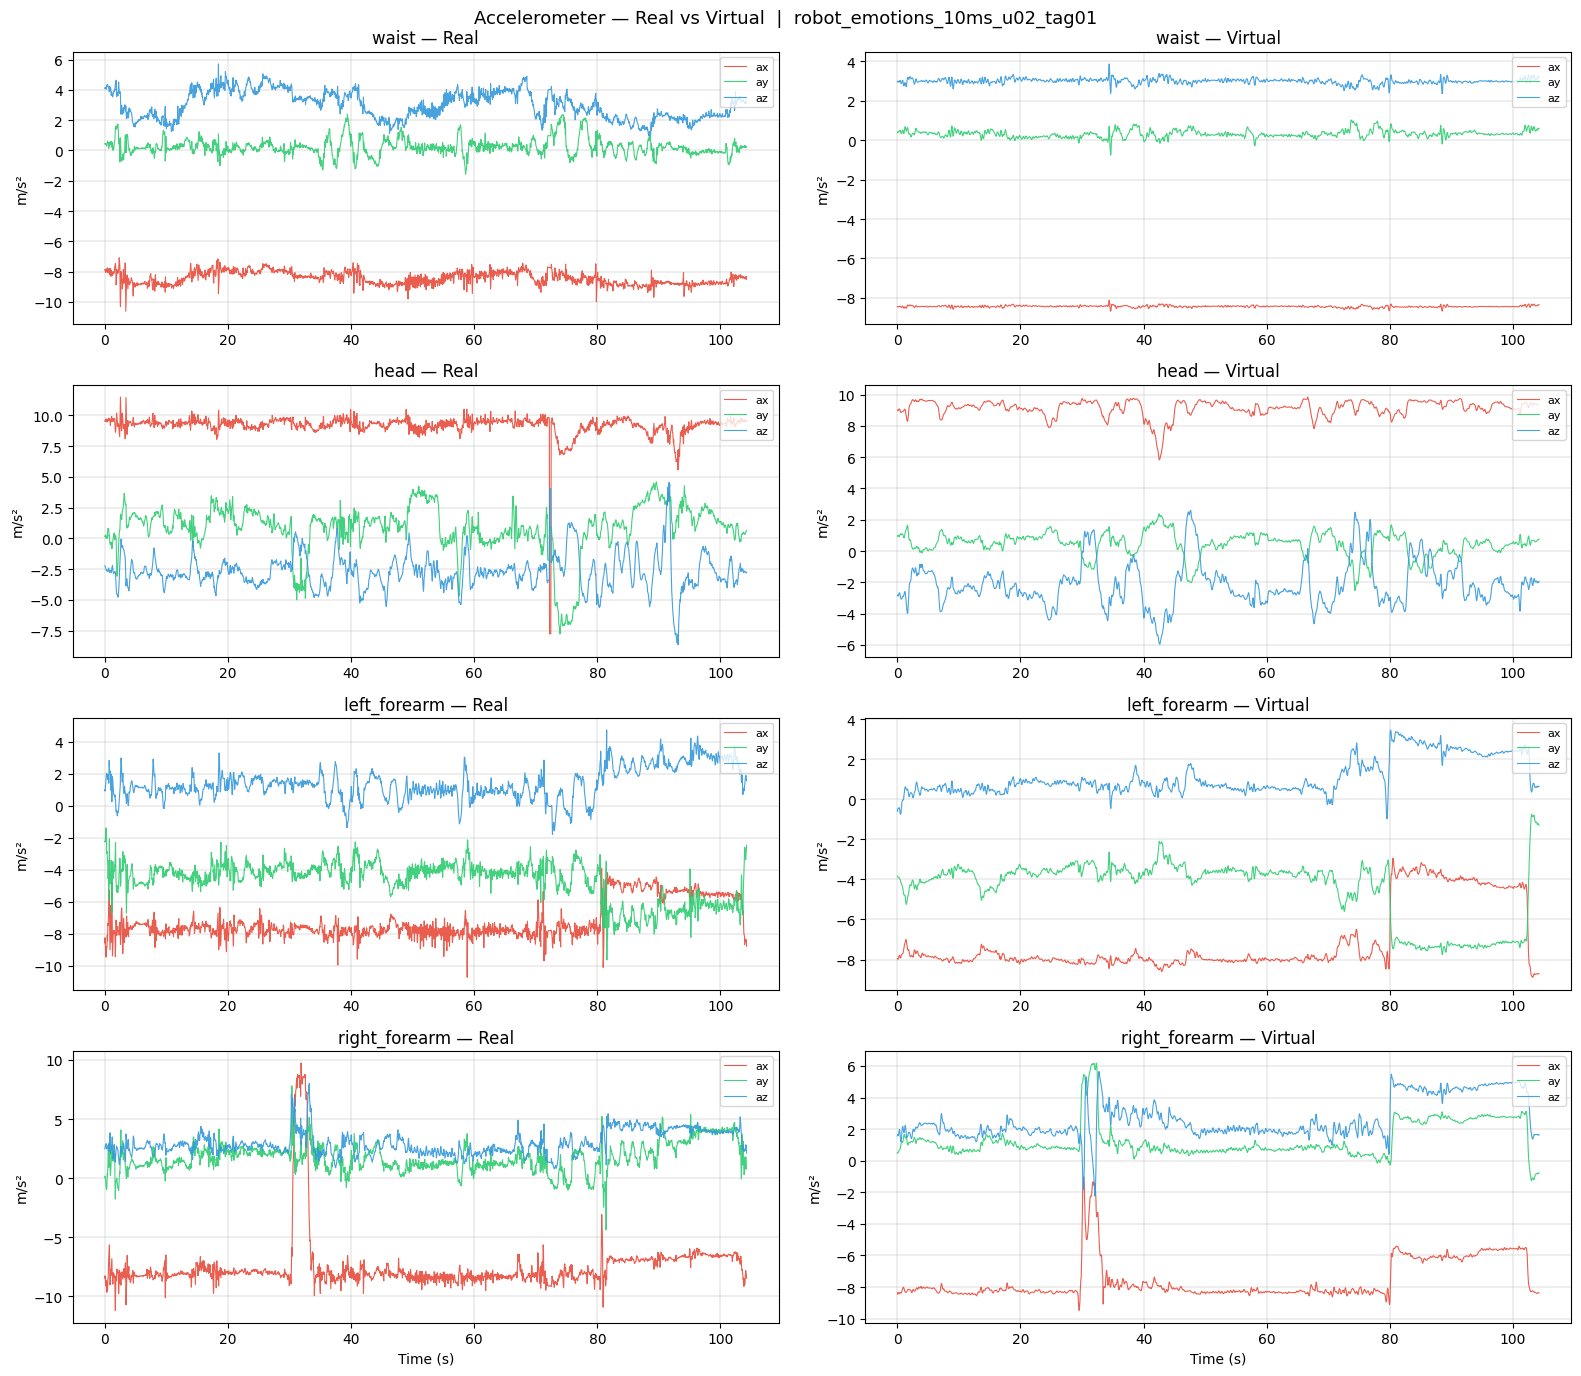

In [11]:
_plot_real_vs_virtual(
    real_t=real_t,
    real_sig=real_acc_bundle["values"],
    virt_t=virt_t,
    virt_sig=virt_data["acc"],
    real_names=real_data["sensor_names"],
    virt_names=virt_data["sensor_names"],
    shared_sensors=shared_sensors,
    axis_labels=["ax", "ay", "az"],
    unit="m/s²",
    suptitle=f"Accelerometer — Real vs Virtual  |  {capture_row['clip_id']}",
)

### Gyroscopes — Real vs. Virtual

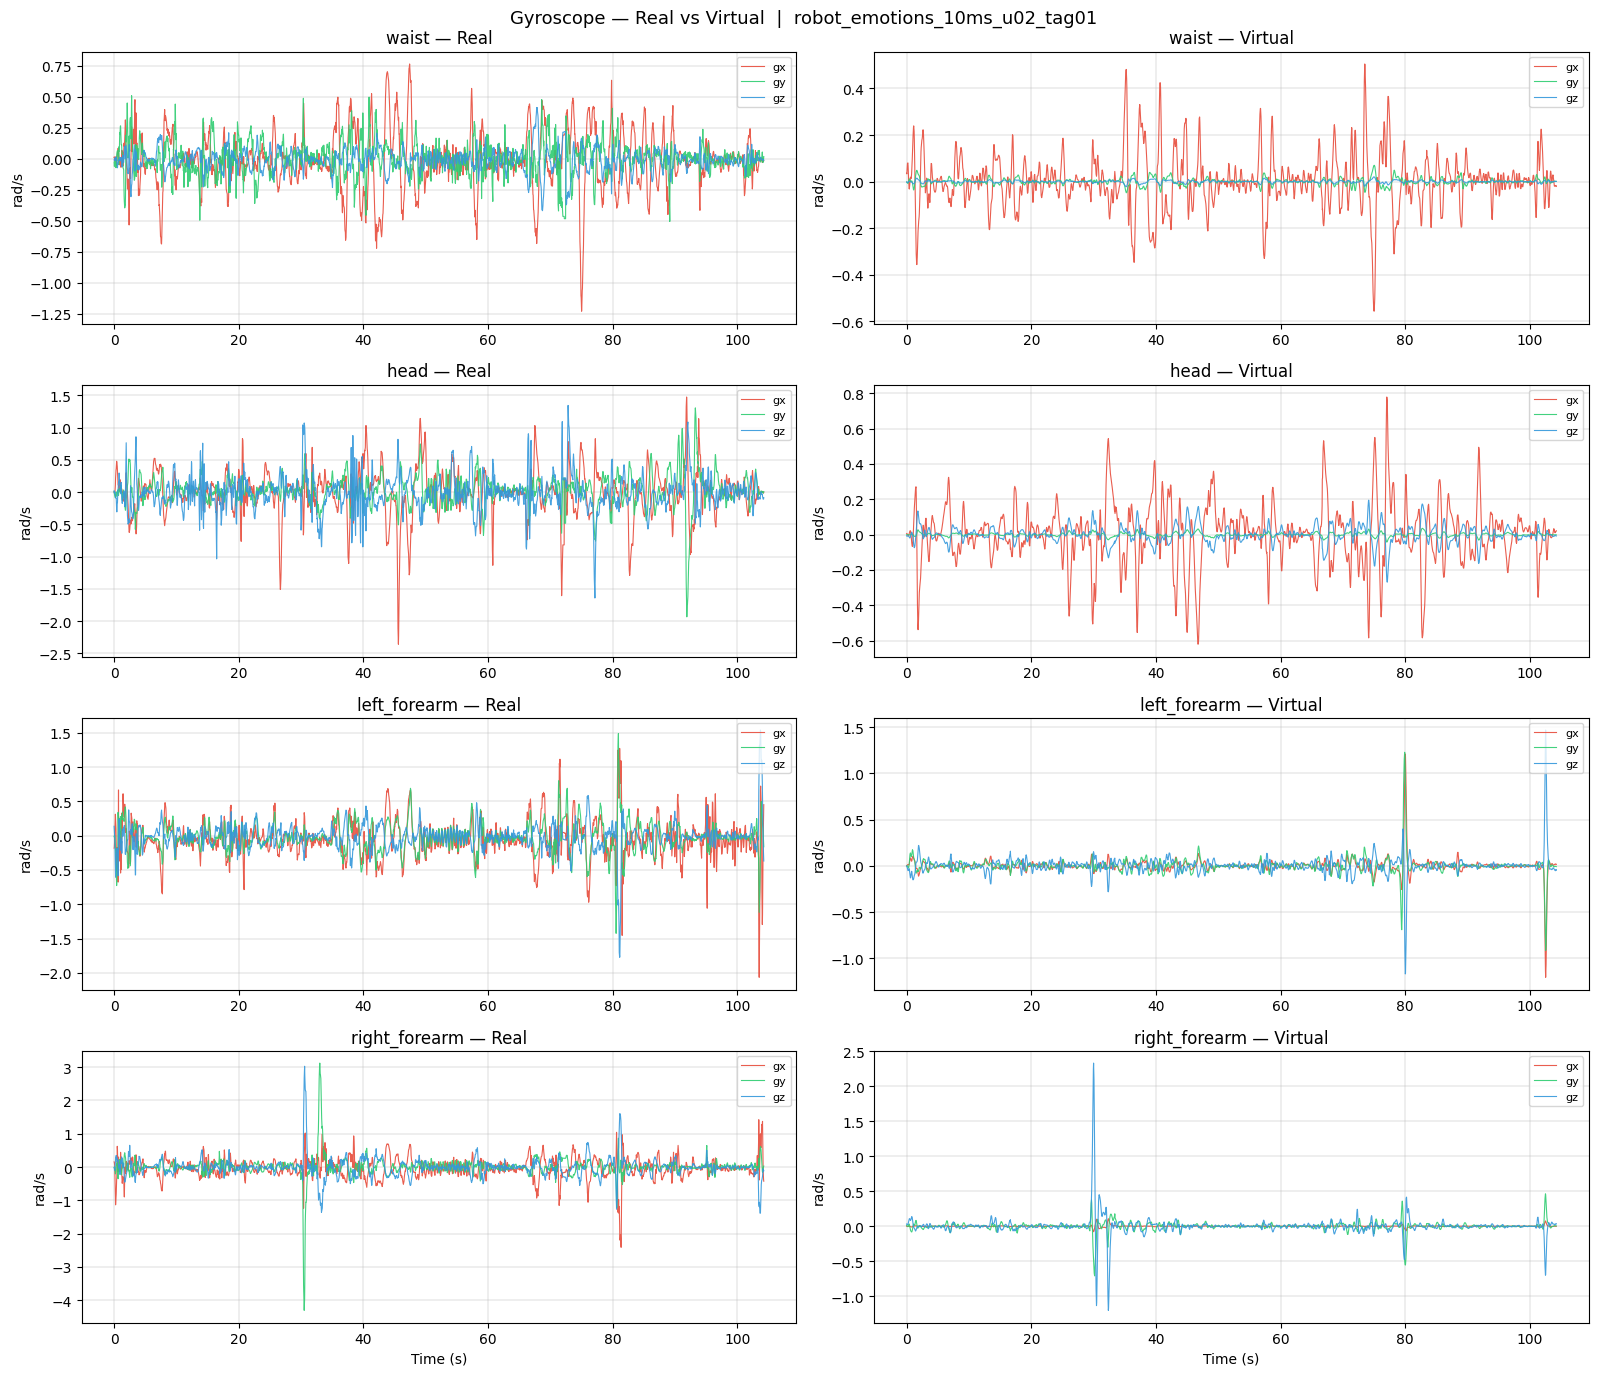

In [12]:
_plot_real_vs_virtual(
    real_t=real_t,
    real_sig=real_gyro_bundle["values"],
    virt_t=virt_t,
    virt_sig=virt_data["gyro"],
    real_names=real_data["sensor_names"],
    virt_names=virt_data["sensor_names"],
    shared_sensors=shared_sensors,
    axis_labels=["gx", "gy", "gz"],
    unit="rad/s",
    suptitle=f"Gyroscope — Real vs Virtual  |  {capture_row['clip_id']}",
)